In [1]:

from pathlib import Path
import time
import numpy as np
from astropy.cosmology import Planck18 as cosmo
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import quad, simps, cumtrapz  # ADD cumtrapz HERE
from scipy.optimize import curve_fit
from scipy.special import erf
import sympy as sp
from scipy.stats import gaussian_kde
import matplotlib.patches as mpatches
from astropy.cosmology import Planck18 as cosmo, z_at_value
from astropy import units as u
from scipy.interpolate import interp1d
from astropy.cosmology import FlatLambdaCDM

In [2]:
# ============================================================================
# TELESCOPE SELECTION
# ============================================================================
TELESCOPE = "D0"
# Other options: "Fast", "Meerkat_incoherent", "Meerkat_coherent", "askap_ics", "askap_flyeye"

TELESCOPE_PARAMS = {


     "d0": {
        "D": 12,
        "eta": 0.6,
        "Trec": 70,
        "Tsky": 3,
        "BW": 336e6,
        "nu_cen": 1.32e9,
        "n_comp": 16,
        "n_dishes": 36,
        "n_chan": 2048,
        "tsamp": 1.265e-3,

    },

    "5d0": {
        "D": 64,
        "eta": 0.6,
        "Trec": 28,
        "Tsky": 3,
        "BW": 340e6,
        "nu_cen": 1.382e9,
        "n_comp": 16,
        "n_dishes": 1,
        "n_chan": int(1024*340/400),
        "n_beams": 13,
        "tsamp": 0.064e-3, #sec

    },
    "25d0": {
        "D": 300,
        "eta": 0.6,
        "Trec": 17,
        "Tsky": 3,
        "BW": 400e6,
        "nu_cen": 1.25e9,
        "n_chan": 2048,
        "n_comp": 8,
        "n_dishes": 1,

        "n_beams": 19,
        "tsamp": 196.608e-6,

    }
}


In [3]:
alpha_intrinsic = -1.5  # Fixed intrinsic spectral index

In [4]:

# EFFECT CONTROL FLAGS
# # ============================================================================
USE_COSMOLOGY = True      # Tozggle Euclidean vs cosmological universe (affects distances, volumes)
USE_SFR = True           
USE_SMEARING = True      
USE_SPECTRAL_INDEX = True 


# USE_COSMOLOGY = False
# USE_SFR = False           
# USE_SMEARING = False    
# USE_SPECTRAL_INDEX = False

# USE_BEAM = True
USE_BEAM = False

# # Luminosity function parameters
LUMINOSITY_FUNCTION = "schechter"  
# LUMINOSITY_FUNCTION = "std" 

In [5]:


# Load selected telescope
if TELESCOPE.lower() not in TELESCOPE_PARAMS:
    raise ValueError(f"Telescope must be one of: {list(TELESCOPE_PARAMS.keys())}")

params = TELESCOPE_PARAMS[TELESCOPE.lower()]

# Physical constants
k = 1.38e-23
c = 3.0e8

# Extract telescope parameters
D = params["D"]
eta = params["eta"]
# n_dishes = params.get("n_dishes", 1)
# mode = params.get("mode", "single")

# n_beams = params.get("n_beams", 1) if mode != "coherent" and mode != "incoherent" else 1
# array_gain_factor = n_dishes if mode == "coherent" else np.sqrt(n_dishes) if mode == "incoherent" else 1
G0 = np.pi * D*D/4 * eta/2.0/k*1e-26
Np = 2





In [6]:
# ============================================================================
# REDSHIFT PARAMETERS
# ============================================================================
dz = 0.01
z_min = 0.01
z_max = 5.0
z_array_opt = np.arange(z_min, z_max, dz)

# Options: "schechter" or "std"

L_STAR = 1e15  # Characteristic luminosity (Jy·kpc²)
ALPHA_SCH = -1.5  # Faint-end slope
L_MIN_SCH = 1e9
L_MAX_SCH = 1e16

# L_std = 2.4e14  # Jy·kpc²
L_std = 1e12  # Jy·kpc²

# Simulation parameters
# theta_max = 2*1.22*c/D/nu_min # please note here
fscale = 0.2 * 1e-7  # FRB rate scaling factor

SNR_threshold = 10
t_obs = 0.001
TARGET_DETECTIONS = 10  # Target 10 detections per z-bin

# Cosmology
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)



# Calculate frequency-dependent scattering term
# freq_powers_scatter = np.array([(nu_min * BW_comp * (i+1))**(-4) for i in range(n_comp)])

np.random.seed(42)


In [7]:
def gaussian_beam_gain(nu, G0, theta, D, c):
    """
    Gaussian beam gain with frequency dependence
    G(ν) = G₀ × exp[−θ²ν²D²×2.355²/(2×1.22²×c²)]
    """
    # Exponent coefficient
    coeff = (theta**2 * D**2 * 2.355**2) / (2 * 1.22**2 * c**2)
    return G0 * np.exp(-coeff * nu**2)

# Pre-calculate constants for speed
_COEFF_CONST = (2.355**2) / (2 * 1.22**2 * (3.0e8**2))

def gaussian_beam_gain_fast(nu_array, G0, theta, D):
    """Optimized version for the inner loop"""
    coeff = theta**2 * D**2 * _COEFF_CONST
    return G0 * np.exp(-coeff * nu_array**2)

def tophat_beam_gain(nu, G0, theta, theta_max):
    """Tophat beam: constant G0 within theta_max/2, zero outside."""
    gain = G0 if theta <= (theta_max / 2) else 0.0
    return np.full_like(nu, gain, dtype=float) if np.ndim(nu) else float(gain)

def SNR(S,t,G,BW,Np,Trec,Tsky):
    return(S*G*np.sqrt(BW*t*Np)/(Trec+Tsky))

In [8]:
def schechter_function(L, L_star, alpha, phi_star=1.0):
    """
    Schechter luminosity function.
    
    φ(L) = φ* (L/L*)^α * exp(-L/L*)
    
    Parameters:
    -----------
    L : float or array
        Luminosity
    L_star : float
        Characteristic luminosity (knee of the function)
    alpha : float
        Faint-end slope (typically negative)
    phi_star : float
        Normalization constant (default: 1.0)
    
    Returns:
    --------
    phi : float or array
        Number density at luminosity L
    """
    x = L / L_star
    return phi_star * x**alpha * np.exp(-x)

In [9]:
def create_truncated_schechter_sampler(L_min, L_max, L_star, alpha):
    """Create sampler for Schechter function truncated between L_min and L_max"""
    L_grid = np.logspace(np.log10(L_min), np.log10(L_max), 2000)
    phi_grid = schechter_function(L_grid, L_star, alpha)
    
    # REMOVE THIS LINE:
    # from scipy.integrate import cumtrapz
    
    cdf = cumtrapz(phi_grid, L_grid, initial=0)
    cdf = cdf / cdf[-1]
    
    inv_cdf = interp1d(cdf, L_grid, kind='linear', 
                       bounds_error=False, fill_value=(L_min, L_max))
    return inv_cdf

In [10]:

# ============================================================================
# CREATE TRUNCATED SCHECHTER SAMPLER FOR EACH Z
# ============================================================================
print("Creating truncated Schechter samplers...")

def create_truncated_schechter_sampler(L_min, L_max, L_star, alpha):
    """Create sampler for Schechter function truncated between L_min and L_max"""
    L_grid = np.logspace(np.log10(L_min), np.log10(L_max), 2000)
    phi_grid = schechter_function(L_grid, L_star, alpha)
    
    from scipy.integrate import cumtrapz
    cdf = cumtrapz(phi_grid, L_grid, initial=0)
    cdf = cdf / cdf[-1]
    
    inv_cdf = interp1d(cdf, L_grid, kind='linear', 
                       bounds_error=False, fill_value=(L_min, L_max))
    return inv_cdf

sampler_cache = {}
print(f"  Done!\n")

def std_sampler(L_candle):
    """Return a fixed luminosity sampler for standard candle model"""
    def sampler(u):
        return L_candle
    return sampler

Creating truncated Schechter samplers...
  Done!



In [11]:
# ============================================================================
# MULTI-TELESCOPE COMPARISON: RUN ALL 3 TELESCOPES AND PLOT TOGETHER
# ============================================================================

print("\n" + "="*100)
print("RUNNING 3-TELESCOPE COMPARISON")
print("="*100 + "\n")

# Store results for each telescope
all_results = {}
colors_tel = {
    "d0": "#1f77b4",      # blue
    "5d0": "#ff7f0e",     # orange
    "25d0": "#2ca02c"     # green
}
labels_tel = {
    "d0": "ASKAP Fly's Eye (12m)",
    "5d0": "Parkes (64m)",
    "25d0": "FAST (300m)"
}


# Define once for the Euclidean branch
H0_km_s_Mpc = cosmo.H0.value if hasattr(cosmo, "H0") else 70.0
DH_Mpc = 299792.458 / H0_km_s_Mpc

# Loop through all telescopes
for tel_key in ["d0", "5d0", "25d0"]:
    print(f"\n{'='*60}")
    print(f"TELESCOPE: {labels_tel[tel_key]}")
    print(f"{'='*60}")

    # Update ALL telescope parameters, not just diameter.
    # Previously only D (and quantities derived purely from D, like G0/
    # theta_max/area_tel) were refreshed here, so every telescope in the
    # loop was silently run with ASKAP's Trec/Tsky/BW/nu_cen/n_comp/n_chan
    # (whatever TELESCOPE = "D0" set up back in the single-telescope cell).
    params = TELESCOPE_PARAMS[tel_key]
    D = params["D"]
    eta = params["eta"]
    Trec = params["Trec"]
    Tsky = params["Tsky"]
    BW = params["BW"]
    nu_cen = params["nu_cen"]
    n_comp = params["n_comp"]
    n_chan = params["n_chan"]

    nu0 = nu_cen
    nu_min = nu_cen - BW / 2
    nu_max = nu_cen + BW / 2
    nu_array = np.linspace(nu_min, nu_max, n_comp + 1)
    BW_comp = BW / n_comp
    BW_chan = BW / n_chan

    G0 = np.pi * D * D / 4 * eta / 2.0 / k * 1e-26
    theta_max = 2 * 1.22 * c / D / nu_min

    # Scattering term depends on nu_min and BW_comp, so it must be
    # recomputed per telescope too (was previously frozen from cell 5).
    freq_powers_scatter = np.array([(nu_min * BW_comp * (i+1))**(-4) for i in range(n_comp)])

    # Recalculate area for this telescope
    fwhm_rad = 1.22 * (c / nu_min) / D
    fwhm_deg = fwhm_rad * (180 / np.pi)
    r_deg = 2.0 * fwhm_deg
    area_tel = np.pi * (r_deg)**2

    print(f"  Diameter: {D} m, G0: {G0:.4e}, theta_max: {theta_max:.6f}")
    print(f"  Trec: {Trec} K, Tsky: {Tsky} K, BW: {BW/1e6:.1f} MHz, nu_cen: {nu_cen/1e9:.3f} GHz, n_comp: {n_comp}, n_chan: {n_chan}")
    print(f"  Sky area: {area_tel:.4f} deg²")

    # Independent seed for repeatability
    np.random.seed(42)

    # Re-compute L_min_by_z for this telescope
    L_min_by_z_new = {}

    for z in z_array_opt:
        if USE_COSMOLOGY:
            dl = cosmo.luminosity_distance(z).value * 1000.0   # kpc
        else:
            dl = (DH_Mpc * z) * 1000.0                          # kpc

        G_max = gaussian_beam_gain(nu0, G0, 0, D, 3.0e8)
        S_min = SNR_threshold * (Trec + Tsky) / (G_max * np.sqrt(BW * t_obs * Np))
        print (S_min)
        if USE_SPECTRAL_INDEX:
            z_factor = (1 + z)**(-1 - alpha_intrinsic)
        else:
            z_factor = 1.0

        L_min = S_min * (dl**2) * z_factor
        L_min_by_z_new[z] = np.clip(L_min, L_MIN_SCH, L_MAX_SCH)

    sampler_cache.clear()

    # Run simulation for this telescope
    results_tel = []
    _INNER_COEFF_CONST_new = (D**2 * 2.355**2) / (2 * 1.22**2 * c**2)
    S_SNR_CONST = np.sqrt(BW_comp * t_obs * Np) / (Trec + Tsky)

    if USE_SPECTRAL_INDEX:
        nu_scaling = (nu_array / nu0)**alpha_intrinsic
    else:
        nu_scaling = np.ones_like(nu_array)

    for z_idx, z in enumerate(z_array_opt):
        zmin = z - 0.5 * dz
        zmax = z + 0.5 * dz
        L_min_z = L_min_by_z_new[z]

        if LUMINOSITY_FUNCTION.lower() == "std":
            if L_min_z > L_std:
                break
        else:
            if L_min_z > 8.952e15:
                break

        if LUMINOSITY_FUNCTION.lower() == "std":
            truncated_sampler = std_sampler(L_std)
        else:
            if L_min_z not in sampler_cache:
                sampler_cache[L_min_z] = create_truncated_schechter_sampler(
                    L_min_z, L_MAX_SCH, L_STAR, ALPHA_SCH
                )
            truncated_sampler = sampler_cache[L_min_z]

        DM = 1000 * z
        wi_z = 0.001 * (1 + z)
        BW_chan_MHz = BW_chan / 1e6
        nu_cen_GHz = nu_cen / 1e9

        if USE_SMEARING:
            w_DM = 8.3e-6 * DM * BW_chan_MHz / (nu_cen_GHz**3)
            w_scatter_comp = (
                1.9e-7 * (DM**1.5) * (1 + (DM**3) * 3.55e-5) * 3 * freq_powers_scatter * 1e-3
            )
            w_scatter = np.sqrt(np.sum(w_scatter_comp**2) / len(w_scatter_comp))
            w_sampling = params["tsamp"] * 1e-3
        else:
            w_DM = 0.0
            w_scatter = 0.0
            w_sampling = 0.0

        w_obs_factor = np.sqrt(wi_z**2 + w_DM**2 + w_scatter**2 + w_sampling**2)

        if USE_COSMOLOGY:
            dl = cosmo.luminosity_distance(z).value * 1000.0
        else:
            dl = (DH_Mpc * z) * 1000.0

        if USE_SPECTRAL_INDEX:
            z_factor = (1 + z)**(-1 - alpha_intrinsic)
        else:
            z_factor = 1.0

        theta_hp = np.sqrt(np.log(2) / (_INNER_COEFF_CONST_new * nu0**2))

        n_generated = 0
        n_detected = 0
        detected_luminosities = []
        detected_snrs = []
        max_iterations = 1000000

        while n_detected < TARGET_DETECTIONS and n_generated < max_iterations:
            n_generated += 1
            theta_frb = theta_max * np.sqrt(np.random.random())

            if theta_frb > 4.0 * theta_hp:
                continue

            lum = float(truncated_sampler(np.random.uniform(0, 1)))
            S0_frb = (lum / (dl**2 * z_factor)) * (wi_z / w_obs_factor)
            S_nu = S0_frb * nu_scaling

            if USE_BEAM:
                G_nu = G0 * np.exp(-(_INNER_COEFF_CONST_new * theta_frb**2) * nu_array**2)
            else:
                G_nu = G0 * np.exp(-(_INNER_COEFF_CONST_new * 0.0**2) * nu_array**2)

            snr_spectrum = S_nu * G_nu * S_SNR_CONST
            snr_coherent = np.sum(snr_spectrum) / np.sqrt(n_comp)

            if snr_coherent > SNR_threshold:
                n_detected += 1
                detected_luminosities.append(lum)
                detected_snrs.append(snr_coherent)

        if n_detected == TARGET_DETECTIONS:
            detection_rate = n_detected / n_generated

            if LUMINOSITY_FUNCTION.lower() == "std":
                N_ratio = 1.0 if L_std >= L_min_z else 0.0
            else:
                L_grid_full =np.logspace(np.log10(L_MIN_SCH), np.log10(L_MAX_SCH), 5000)
                phi_grid_full = schechter_function(L_grid_full, L_STAR, ALPHA_SCH)
                cdf_full = cumtrapz(phi_grid_full, L_grid_full, initial=0)
                cdf_full /= cdf_full[-1]
                cdf_interp = interp1d(L_grid_full, cdf_full, kind="linear")
                N_ratio = 1.0 - cdf_interp(L_min_z)

            if USE_COSMOLOGY:
                dt = (cosmo.age(zmin).value - cosmo.age(zmax).value) * 1e9
                dvol = (
                    cosmo.comoving_volume(zmax).value - cosmo.comoving_volume(zmin).value
                ) * (area_tel / (4.0 * np.pi * ((180.0 / np.pi)**2)))
            else:
                r_Mpc = DH_Mpc * z
                dr_Mpc = DH_Mpc * dz
                area_sr = area_tel * (np.pi / 180.0)**2
                dvol = (r_Mpc**2) * dr_Mpc * area_sr
                dr_m = dr_Mpc * 3.0857e22
                dt = dr_m / c / (3600.0 * 24.0 * 365.0)

            if USE_SFR:
                psi = 0.015 * ((1 + z)**2.7) / (1 + ((1 + z) / 2.9)**5.6)
            else:
                psi = 0.015

            nfrb_sfr = psi * dvol * dt * fscale
            n_total_population = detection_rate * N_ratio * nfrb_sfr

            results_tel.append({
                "z": z,
                "DM": DM,
                "n_total_population": n_total_population
            })

            if z_idx % 50 == 0:
                print(f"  z={z:.2f}: Pop {n_total_population:.1f}")

    print(f"  ✓ Results: {len(results_tel)} redshift bins")
    all_results[tel_key] = results_tel

# Restore original parameters


print(f"\n{'='*100}")
print("CREATING COMBINED HISTOGRAM PLOT")
print(f"{'='*100}\n")



RUNNING 3-TELESCOPE COMPARISON


TELESCOPE: ASKAP Fly's Eye (12m)
  Diameter: 12 m, G0: 2.4586e-02, theta_max: 0.052951
  Trec: 70 K, Tsky: 3 K, BW: 336.0 MHz, nu_cen: 1.320 GHz, n_comp: 16, n_chan: 2048
  Sky area: 28.9168 deg²
36.219602672625975
36.219602672625975
36.219602672625975
36.219602672625975
36.219602672625975
36.219602672625975
36.219602672625975
36.219602672625975
36.219602672625975
36.219602672625975
36.219602672625975
36.219602672625975
36.219602672625975
36.219602672625975
36.219602672625975
36.219602672625975
36.219602672625975
36.219602672625975
36.219602672625975
36.219602672625975
36.219602672625975
36.219602672625975
36.219602672625975
36.219602672625975
36.219602672625975
36.219602672625975
36.219602672625975
36.219602672625975
36.219602672625975
36.219602672625975
36.219602672625975
36.219602672625975
36.219602672625975
36.219602672625975
36.219602672625975
36.219602672625975
36.219602672625975
36.219602672625975
36.219602672625975
36.219602672625975
36.2196026

/tmp/ipykernel_664894/4221973470.py:12: DeprecationWarning: 'scipy.integrate.cumtrapz' is deprecated in favour of 'scipy.integrate.cumulative_trapezoid' and will be removed in SciPy 1.14.0
  cdf = cumtrapz(phi_grid, L_grid, initial=0)
/tmp/ipykernel_664894/1652805131.py:197: DeprecationWarning: 'scipy.integrate.cumtrapz' is deprecated in favour of 'scipy.integrate.cumulative_trapezoid' and will be removed in SciPy 1.14.0
  cdf_full = cumtrapz(phi_grid_full, L_grid_full, initial=0)


  z=1.51: Pop 0.0
  ✓ Results: 165 redshift bins

TELESCOPE: Parkes (64m)
  Diameter: 64 m, G0: 6.9935e-01, theta_max: 0.009437
  Trec: 28 K, Tsky: 3 K, BW: 340.0 MHz, nu_cen: 1.382 GHz, n_comp: 16, n_chan: 870
  Sky area: 0.9184 deg²
0.5375455114667145
0.5375455114667145
0.5375455114667145
0.5375455114667145
0.5375455114667145
0.5375455114667145
0.5375455114667145
0.5375455114667145
0.5375455114667145
0.5375455114667145
0.5375455114667145
0.5375455114667145
0.5375455114667145
0.5375455114667145
0.5375455114667145
0.5375455114667145
0.5375455114667145
0.5375455114667145
0.5375455114667145
0.5375455114667145
0.5375455114667145
0.5375455114667145
0.5375455114667145
0.5375455114667145
0.5375455114667145
0.5375455114667145
0.5375455114667145
0.5375455114667145
0.5375455114667145
0.5375455114667145
0.5375455114667145
0.5375455114667145
0.5375455114667145
0.5375455114667145
0.5375455114667145
0.5375455114667145
0.5375455114667145
0.5375455114667145
0.5375455114667145
0.5375455114667145
0.537

✓ Plot created with PDF histograms and configuration box



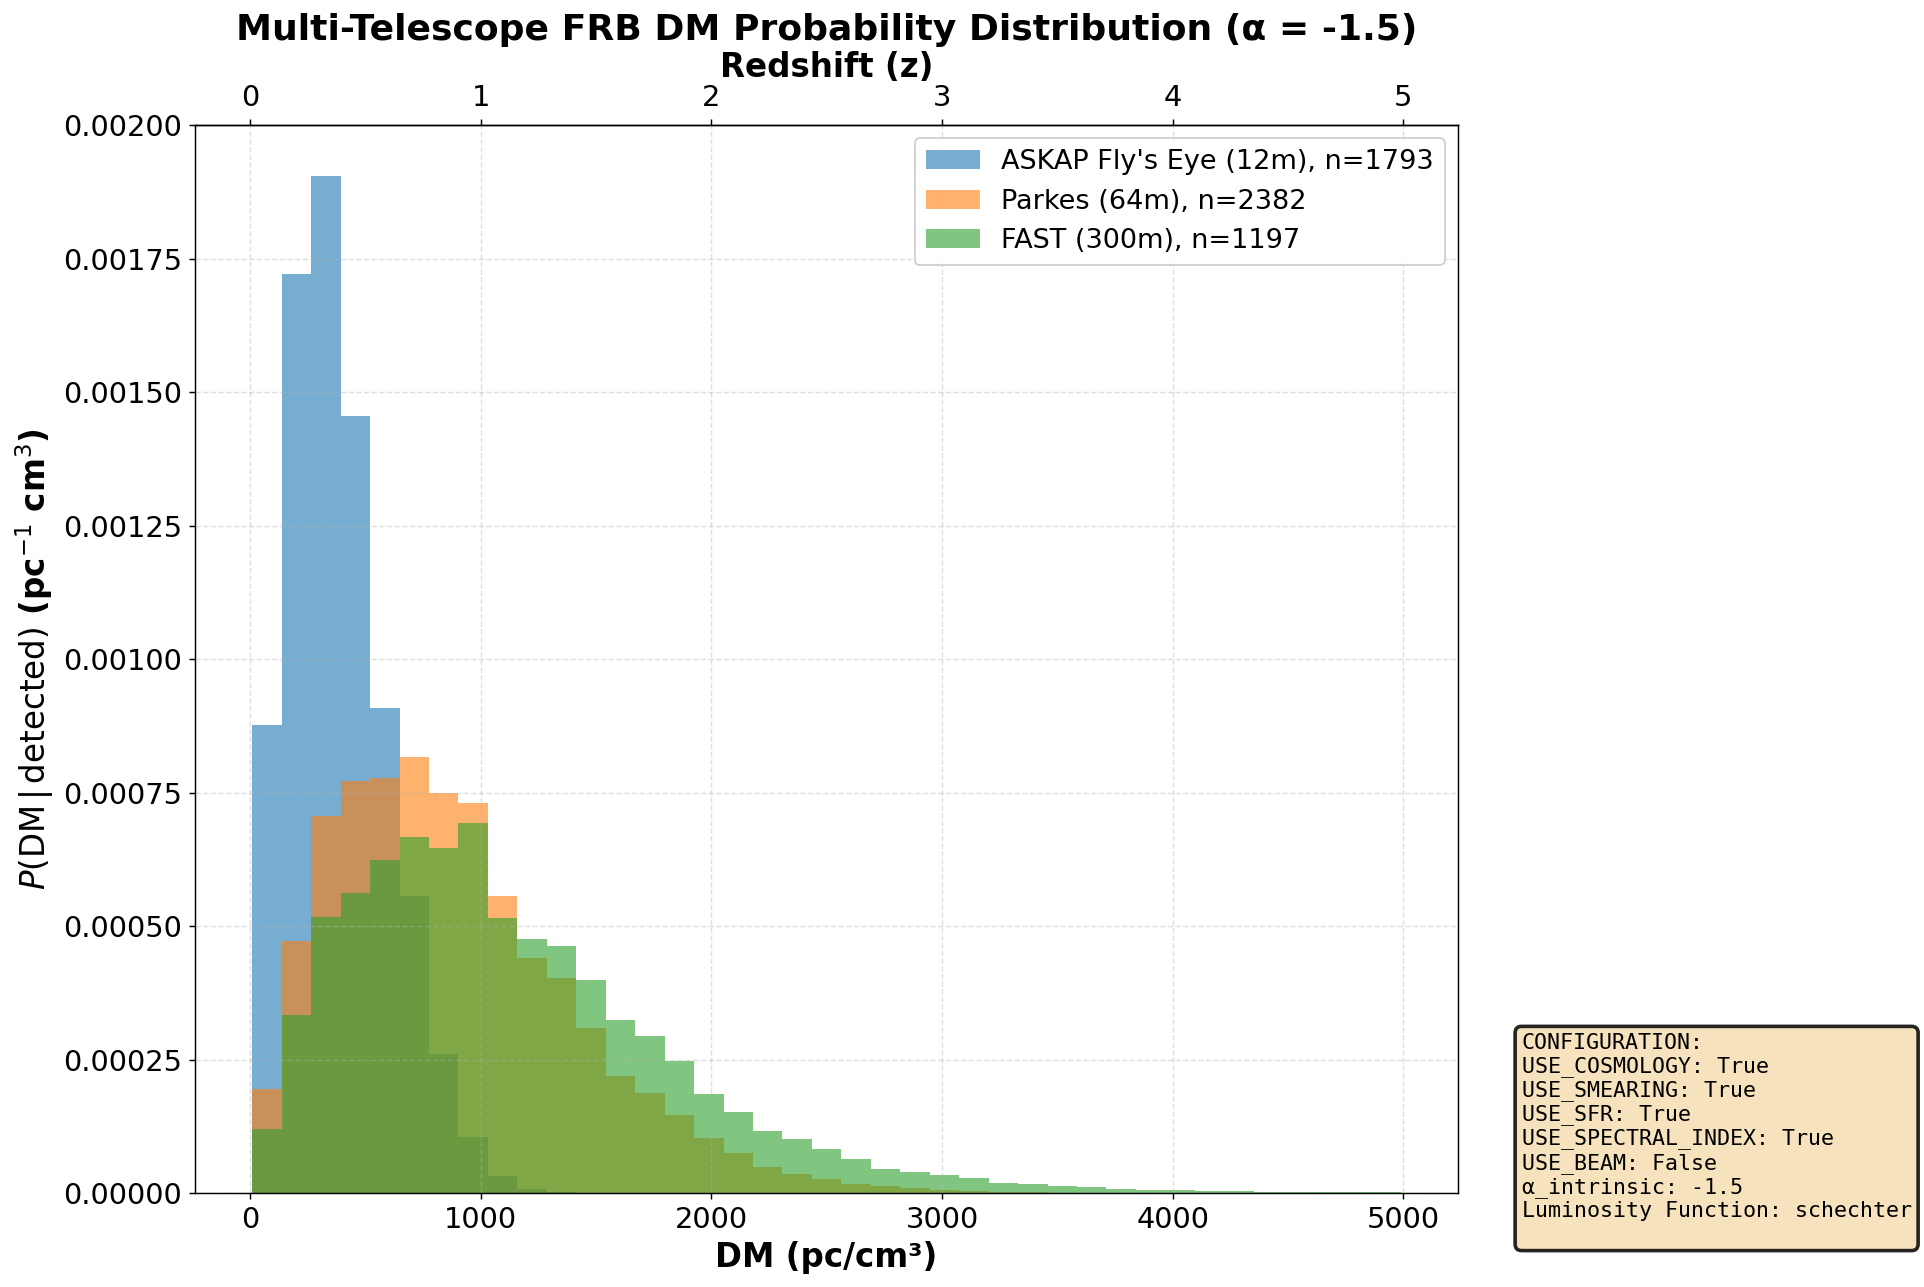

MULTI-TELESCOPE COMPARISON COMPLETE


In [12]:
fig, ax = plt.subplots(figsize=(15, 10), dpi=130)

# Find global DM range
dm_min = min([1000*r[0]['z'] for r in [all_results[k] for k in all_results if len(all_results[k]) > 0]])
dm_max = max([1000*r[-1]['z'] for r in [all_results[k] for k in all_results if len(all_results[k]) > 0]])
common_bins = np.linspace(dm_min, dm_max, 40)
lables_tel = {
    "d0": "ASKAP Fly's Eye (12m)",
    "5d0": "Parkes (64m)",
    "25d0": "FAST (300m)"
}
# Plot histograms for each telescope
for tel_key in ['d0', '5d0', '25d0']:
    if tel_key in all_results and len(all_results[tel_key]) > 0:
        results = all_results[tel_key]
        DMs = np.array([r['DM'] for r in results])
        pops = np.array([r['n_total_population'] for r in results])
        
        # Create histogram as a Probability Density Function (PDF)
        # density=True ensures the integral over the histogram = 1.0 (P(DM|detected))
        ax.hist(DMs, bins=common_bins, weights=pops, density=True, alpha=0.6,
                label=f'{labels_tel[tel_key]}, n={int(pops.sum())}', color=colors_tel[tel_key], linewidth=1.5)

# Create secondary x-axis for redshift (z)
ax2 = ax.secondary_xaxis('top', functions=(lambda x: x/1000, lambda x: x*1000))
ax2.set_xlabel('Redshift (z)', fontsize=18, fontweight='bold')
ax2.tick_params(axis='x', labelsize=16)

# Set labels and title
ax.set_xlabel('DM (pc/cm³)', fontsize=18, fontweight='bold')
ax.set_ylabel(r'$P(\mathrm{DM}\,|\,\mathrm{detected})$ (pc$^{-1}$ cm$^3$)', fontsize=18, fontweight='bold')
title = f'Multi-Telescope FRB DM Probability Distribution (α = {alpha_intrinsic})' if USE_SPECTRAL_INDEX else 'Multi-Telescope FRB DM Probability Distribution'
ax.set_title(title, fontsize=20, fontweight='bold')

# Increase tick label sizes
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)

# Add grid for both x and y
ax.grid(True, alpha=0.4, linestyle='--', linewidth=0.8)

# Increase legend font size
ax.legend(fontsize=15, loc='upper right', framealpha=0.95)

# Create configuration text box
config_text = (
    f"CONFIGURATION:\n"
    f"USE_COSMOLOGY: {USE_COSMOLOGY}\n"
    f"USE_SMEARING: {USE_SMEARING}\n"
    f"USE_SFR: {USE_SFR}\n"
    f"USE_SPECTRAL_INDEX: {USE_SPECTRAL_INDEX}\n"
     f"USE_BEAM: {USE_BEAM}\n"
)
if USE_SPECTRAL_INDEX:
    config_text += f"α_intrinsic: {alpha_intrinsic}\n"
config_text += f"Luminosity Function: {LUMINOSITY_FUNCTION}\n"

props = dict(boxstyle='round', facecolor='wheat', alpha=0.85, edgecolor='black', linewidth=2)
ax.text(1.05, 0.15, config_text, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=props, family='monospace')

plt.tight_layout()
# plt.savefig('multi_telescope_normalized_comparison.png', dpi=150, bbox_inches='tight')
print("✓ Plot created with PDF histograms and configuration box\n")
plt.show()


print(f"{'='*100}")
print("MULTI-TELESCOPE COMPARISON COMPLETE")
print(f"{'='*100}")

In [13]:
import pickle
# out_path = "mc_all_results_3tel_real.pkl"
# out_path = "mc_all_results_3tel_euc.pkl"
out_path = "mc_all_results_3tel_beam.pkl"


with open(out_path, "wb") as f:
    pickle.dump(all_results, f)

In [14]:
# import pickle
# out_path = "mc_all_results_cos_std.pkl"
# # out_path = "mc_all_results_cos_sch.pkl"
# # out_path = "mc_all_results_cos_sfr_sch.pkl"

# # out_path = "mc_all_results_cos_sfr_sch_smear.pkl"
# # out_path = "mc_all_results_alpha_minus_2.pkl"
# with open(out_path, "wb") as f:
#     pickle.dump(all_results, f)
# print("Saved MC pickle to", out_path)

In [15]:
# ============================================================================
# LOAD REAL TELESCOPE DM DISTRIBUTIONS (READ FROM 'DM' COLUMN)
# ============================================================================

import pandas as pd
from pathlib import Path
import numpy as np

print("Loading real telescope DM data (from 'DM' column)...\n")

real_data_dir = Path("DM_distribution_real_data")

# Robust CSV loading function - specifically read DM column
def load_dm_data(file_path):
    """Load DM data from CSV file, extracting 'DM' column"""
    try:
        # Try to read CSV and extract 'DM' column
        data = pd.read_csv(file_path)
        if 'DM' in data.columns:
            dm_array = data['DM'].values
            dm_array = dm_array[~np.isnan(dm_array)]  # Remove NaN values
            return dm_array
        else:
            # If no 'DM' column, try first column
            print(f"    Warning: No 'DM' column found. Columns: {list(data.columns)}")
            dm_array = data.iloc[:, 0].values
            dm_array = dm_array[~np.isnan(dm_array)]
            return dm_array
    except:
        try:
            # Fallback: read with header=None and try different approaches
            data = pd.read_csv(file_path, header=None, on_bad_lines='skip')
            dm_array = data.values.flatten()
            dm_array = dm_array[~np.isnan(dm_array)]
            return dm_array
        except:
            try:
                # Last resort: numpy.loadtxt
                dm_array = np.loadtxt(file_path, delimiter=',', dtype=float)
                if dm_array.ndim == 1:
                    return dm_array
                else:
                    return dm_array.flatten()
            except:
                print(f"    Error: Could not parse {file_path}")
                return np.array([])

# Load real DM distributions
real_dm_data = {}
tel_files = {
    "askap_flyeye": "askap_flyeye.csv",
    "pks": "parkes.csv",
    "fast": "fast.csv",
    "askap_ics": "askap_ics.csv",
    "meerkat_cb": "meerkat_CB.csv",
    "meerkat_ib": "meerkat_IB.csv",
    "apertif": "apertif.csv",
    "dsa110": "dsa-110.csv",
}

for tel_name, file_name in tel_files.items():
    file_path = real_data_dir / file_name
    if file_path.exists():
        dm_array = load_dm_data(file_path)
        real_dm_data[tel_name] = dm_array
        if len(dm_array) > 0:
            print(f"✓ {tel_name:15s}: Loaded {len(dm_array):4d} DM values, range: [{np.min(dm_array):7.1f}, {np.max(dm_array):7.1f}]")
        else:
            print(f"✗ {tel_name:15s}: No data loaded")
    else:
        print(f"✗ {tel_name:15s}: File not found")

print(f"\n✓ Loaded {len(real_dm_data)} telescope datasets\n")

Loading real telescope DM data (from 'DM' column)...

✓ askap_flyeye   : Loaded   25 DM values, range: [  114.1,   991.7]
✓ pks            : Loaded   30 DM values, range: [  169.0,  3337.9]
✓ fast           : Loaded   13 DM values, range: [  765.0,  2765.2]
✓ askap_ics      : Loaded   43 DM values, range: [  206.0,  1785.3]
✓ meerkat_cb     : Loaded   18 DM values, range: [  433.6,  2660.4]
✓ meerkat_ib     : Loaded   15 DM values, range: [  433.6,  1990.0]
✓ apertif        : Loaded   24 DM values, range: [  246.5,  2778.0]
✓ dsa110         : Loaded   12 DM values, range: [  111.0,   706.7]

✓ Loaded 8 telescope datasets



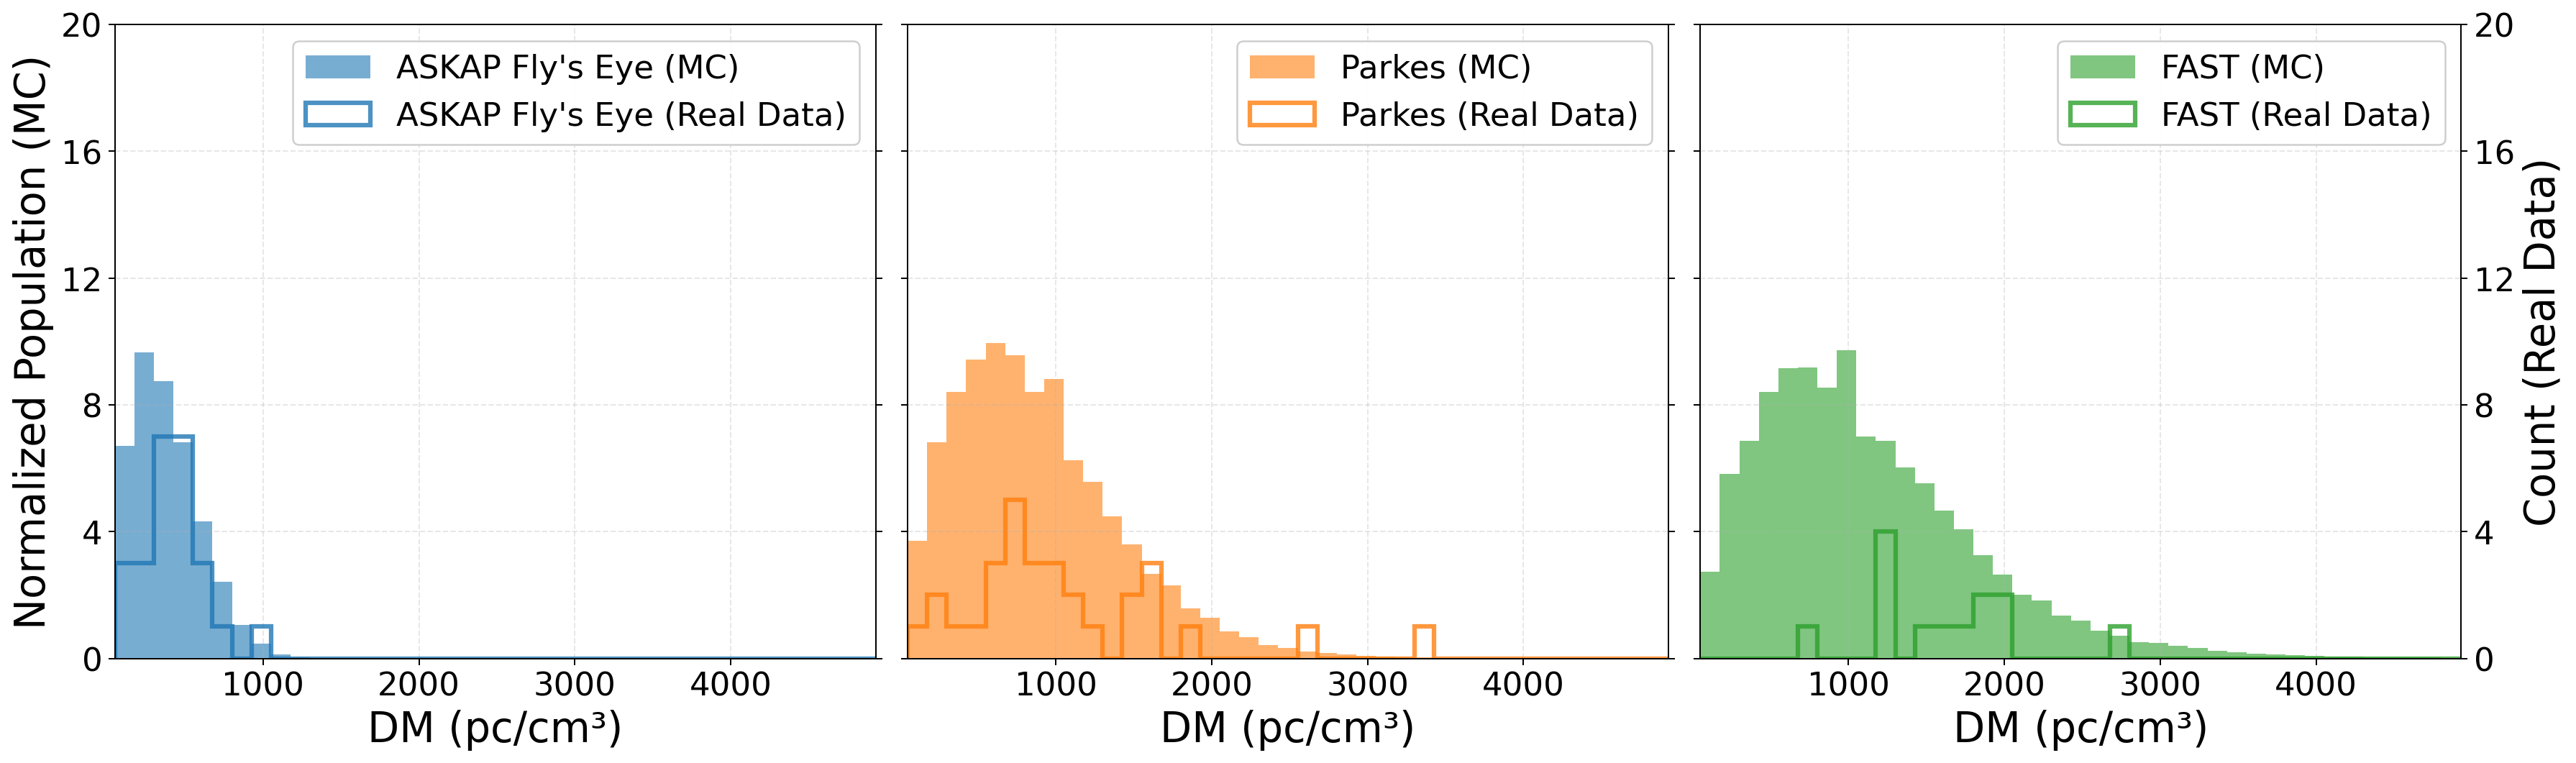

In [16]:


# Global DM range across all real telescopes
all_real_dms = []
for dm_array in real_dm_data.values():
    all_real_dms.extend(dm_array)

dm_min_real = np.percentile(all_real_dms, 1)
dm_max_real = np.percentile(all_real_dms, 99)
common_bins_real = np.linspace(dm_min_real, dm_max_real, 50)


real_tel_labels = {
    "askap_flyeye": "ASKAP Fly's Eye (Real Data)",
    "pks": "Parkes (Real Data)",
    "fast": "FAST (Real Data)",
    "askap_ics": "ASKAP ICS",
    "meerkat_cb": "MeerKAT CB",
    "meerkat_ib": "MeerKAT IB",
    "apertif": "Apertif",
    "dsa110": "DSA-110",
}

labels_tel_MC = {
    "d0": "ASKAP Fly's Eye (MC)",
    "5d0": "Parkes (MC)",
    "25d0": "FAST (MC)"
}

import math

def nice_ceiling(value, steps=(1, 2, 2.5, 5, 10)):
    """Round value up to a visually clean number (1,2,2.5,5,10 x 10^n)."""
    if value <= 0:
        return 1
    exponent = math.floor(math.log10(value))
    for step in steps:
        candidate = step * 10**exponent
        if candidate >= value:
            return candidate
    return 10 * 10**exponent


fig, axes = plt.subplots(1, 3, figsize=(20, 6), dpi=180)

all_dms_pairs = []
for mc_key, real_key, _ in [("d0", "askap_flyeye", colors_tel["d0"]),
                              ("5d0", "pks", colors_tel["5d0"]),
                              ("25d0", "fast", colors_tel["25d0"])]:
    if mc_key in all_results:
        mc_results = all_results[mc_key]
        mc_dms = np.array([r['DM'] for r in mc_results])
        all_dms_pairs.extend(mc_dms)
    if real_key in real_dm_data:
        all_dms_pairs.extend(real_dm_data[real_key])

dm_min_global = np.percentile(all_dms_pairs, 1)
dm_max_global = np.percentile(all_dms_pairs, 99)
common_bins_global = np.linspace(dm_min_global, dm_max_global, 40)

pairs = [
    ("d0", "askap_flyeye", colors_tel["d0"]),
    ("5d0", "pks", colors_tel["5d0"]),
    ("25d0", "fast", colors_tel["25d0"]),
]

# --- Pre-compute a SINGLE shared y max for BOTH left and right axes ---
combined_max = 0.0

for mc_key, real_key, _ in pairs:
    if mc_key in all_results:
        mc_results = all_results[mc_key]
        mc_pops = np.array([r['n_total_population'] for r in mc_results])
        if len(mc_pops) > 0:
            mc_max = mc_pops.max()
            mc_pops_norm = mc_pops / mc_max
            counts, _ = np.histogram(
                np.array([r['DM'] for r in mc_results]),
                bins=common_bins_global, weights=mc_pops_norm
            )
            combined_max = max(combined_max, counts.max())

    if real_key in real_dm_data:
        real_dms = real_dm_data[real_key]
        real_counts, _ = np.histogram(real_dms, bins=common_bins_global)
        combined_max = max(combined_max, real_counts.max())

# round up to a clean shared value, e.g. 9 -> 10, 8.3 -> 10, 4.2 -> 5, etc.
shared_ymax = nice_ceiling(combined_max * 1.05)
shared_ylim = (0, shared_ymax)
n_ticks = 6  # tweak to taste
shared_ticks = np.linspace(0, shared_ymax, n_ticks)
# ------------------------------------------------------------------------

for ax_idx, (mc_key, real_key, color) in enumerate(pairs):
    ax_left = axes[ax_idx]
    ax_right = ax_left.twinx()

    if mc_key in all_results:
        mc_results = all_results[mc_key]
        mc_dms = np.array([r['DM'] for r in mc_results])
        mc_pops = np.array([r['n_total_population'] for r in mc_results])
    else:
        mc_dms = np.array([])
        mc_pops = np.array([])

    real_dms = real_dm_data[real_key]

    if len(mc_dms) > 0 and len(real_dms) > 0:
        from scipy.stats import ks_2samp
        ks_stat, p_value = ks_2samp(mc_dms, real_dms)
    else:
        p_value = np.nan

    mc_max = mc_pops.max() if len(mc_pops) > 0 else 1.0

    if len(mc_dms) > 0:
        mc_pops_norm = mc_pops / mc_max
        ax_left.hist(mc_dms, bins=common_bins_global, weights=mc_pops_norm, alpha=0.6,
                label=f'{labels_tel_MC[mc_key]} ', color=color, linewidth=1.5, histtype='stepfilled')

    ax_right.hist(real_dms, bins=common_bins_global, alpha=0.8,
            label=real_tel_labels[real_key], color=color,
            linewidth=2.5, histtype='step', linestyle='-', edgecolor=color)

    # Unified x scale
    ax_left.set_xlim(dm_min_global, dm_max_global)

    # SAME range + SAME tick positions on both axes, every panel
    ax_left.set_ylim(*shared_ylim)
    ax_right.set_ylim(*shared_ylim)
    ax_left.set_yticks(shared_ticks)
    ax_right.set_yticks(shared_ticks)

    ax_left.set_xlabel('DM (pc/cm³)', fontsize=23)
    ax_left.tick_params(axis='x', labelsize=18)
    ax_left.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)

    if ax_idx == 0:
        ax_left.set_ylabel('Normalized Population (MC)', fontsize=23)
        ax_left.tick_params(axis='y', labelsize=18)
        ax_right.tick_params(axis='y', labelleft=False, labelright=False)
    elif ax_idx == len(pairs) - 1:
        ax_left.tick_params(axis='y', labelleft=False, labelright=False)
        ax_right.set_ylabel('Count (Real Data)', fontsize=23)
        ax_right.tick_params(axis='y', labelsize=18)
    else:
        ax_left.tick_params(axis='y', labelleft=False, labelright=False)
        ax_right.tick_params(axis='y', labelleft=False, labelright=False)

    lines_left, labels_left = ax_left.get_legend_handles_labels()
    lines_right, labels_right = ax_right.get_legend_handles_labels()
    ax_left.legend(lines_left + lines_right, labels_left + labels_right,
                  fontsize=18, loc='upper right', framealpha=0.95)

plt.tight_layout()
plt.show()